# 🛍️ Retail Store Demand Forecasting Using Time Series Machine Learning

### Forecasting future sales demand to improve inventory planning, reduce stockouts, and support data-driven retail decisions.

### 📌 Project Information

**Project Type:** Time Series Forecasting / Machine Learning  

**Industry:** Retail / Inventory Management  

**Goal:** Predict future sales demand using historical sales patterns and machine learning techniques.

**Dataset:** Kaggle Demand Forecasting Challenge

**Tools & Technologies:**  
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost (optional)


# 📌 Project Overview

Demand forecasting is one of the most important challenges in retail businesses. Predicting future product demand accurately helps companies optimize inventory levels, reduce operational costs, and improve customer satisfaction.

Poor demand forecasting can lead to major business problems such as:

- **Overstocking:** Excess inventory leading to higher storage costs and wasted products.
- **Stockouts:** Running out of products, resulting in lost sales and poor customer experience.
- **Inefficient inventory planning:** Difficulty balancing supply and demand.

In this project, we aim to build a **time series forecasting machine learning pipeline** to predict future sales demand using historical retail sales data.

Rather than focusing only on prediction accuracy, this project also aims to:

- Understand sales patterns over time
- Identify seasonality and trends
- Analyze store and item behavior
- Build forecasting features using historical information
- Compare multiple machine learning models
- Generate business insights for inventory planning

The final goal is to create a **portfolio-ready forecasting project** that reflects real-world data science thinking and machine learning workflow.

# ❓ Business Problem

Retail businesses often struggle to estimate future demand accurately.

If demand is underestimated, products may become unavailable (**stockout**), causing revenue loss and customer dissatisfaction.

If demand is overestimated, businesses may hold unnecessary inventory (**overstock**), increasing storage costs and reducing operational efficiency.

The challenge is:

> **Can we accurately forecast future product sales using historical demand patterns?**

To answer this question, we will use **time series forecasting techniques** and machine learning models to predict future sales demand.

# 🎯 Project Objectives

### Primary Objective

The primary goal of this project is to:

> **Predict future sales demand using historical retail sales data.**

---

### Secondary Objectives

By the end of this project, we aim to:

- Understand historical sales behavior
- Detect trends and seasonality in sales data
- Explore store-level and item-level demand patterns
- Build meaningful time-based forecasting features
- Compare different machine learning models
- Evaluate forecasting performance using regression metrics
- Generate business recommendations for inventory planning

---

### Expected Business Impact

Accurate demand forecasting can help businesses:

✅ Reduce stock shortages (**stockout**)  
✅ Minimize excess inventory (**overstock**)  
✅ Improve replenishment planning  
✅ Support better business decisions through data

# ⚙️ Machine Learning Pipeline

Business Problem Definition  
↓  
Dataset Understanding  
↓  
Exploratory Data Analysis (EDA)  
↓  
Time Series Pattern Analysis  
↓  
Feature Engineering  
(Time Features, Lag Features, Rolling Features)  
↓  
Data Preprocessing  
↓  
Train & Test Data Understanding  
(Kaggle Provided Split)  
↓  
Validation Strategy for Forecasting  
↓  
Baseline Model  
↓  
Machine Learning Model Training  
↓  
Model Comparison  
↓  
Forecast Evaluation  
(MAE, RMSE, R²)  
↓  
Prediction Visualization  
↓  
Business Insights & Recommendations  
↓  
Final Conclusion

# 📚 Importing Libraries & Loading Data

In this section, we import the required Python libraries for data manipulation, visualization, and machine learning.

We also load the training and testing datasets that will be used throughout the forecasting pipeline.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ==========================
# Data Manipulation
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Data Visualization
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Settings
# ==========================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

plt.style.use('default')
sns.set_style('whitegrid')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [3]:
# Load datasets

train_df = pd.read_csv('/content/drive/MyDrive/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/test.csv')

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (913000, 4)
Test Shape: (45000, 4)


In [4]:
# Preview datasets

display(train_df.head())

display(test_df.head())

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [5]:
train_df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


# 🔍 Dataset Understanding

Before building forecasting models, it is important to understand the structure of the dataset.

In this section, we will explore:

- Dataset dimensions
- Feature types
- Missing values
- Duplicate records
- Statistical overview
- Time coverage of the data

Understanding the dataset helps us detect potential issues early and better prepare the data for forecasting.

In [6]:
# Dataset overview

print("Train Dataset Info")
print("-" * 50)
train_df.info()

print("\n")

print("Test Dataset Info")
print("-" * 50)
test_df.info()

Train Dataset Info
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


Test Dataset Info
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      45000 non-null  int64 
 1   date    45000 non-null  object
 2   store   45000 non-null  int64 
 3   item    45000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.4+ MB


In [7]:
# Missing values

train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()

print("Train Missing Values:")
display(train_missing)

print("\nTest Missing Values:")
display(test_missing)

Train Missing Values:


,0
date,0
store,0
item,0
sales,0



Test Missing Values:


,0
id,0
date,0
store,0
item,0


In [8]:
# Duplicate rows

print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


In [9]:
# Statistical summary

display(train_df.describe())

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [10]:
# Convert date column to datetime

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

print("Train Date Range:")
print(train_df['date'].min(), "→", train_df['date'].max())

print("\nTest Date Range:")
print(test_df['date'].min(), "→", test_df['date'].max())

Train Date Range:
2013-01-01 00:00:00 → 2017-12-31 00:00:00

Test Date Range:
2018-01-01 00:00:00 → 2018-03-31 00:00:00


# 📊 Exploratory Data Analysis (EDA)

Before building forecasting models, it is important to understand sales behavior and identify hidden patterns in the data.

In this section, we will explore:

- Sales distribution
- Time-based trends
- Seasonality patterns
- Store behavior
- Item demand patterns

The goal is to better understand how sales change over time and what factors may influence future demand.

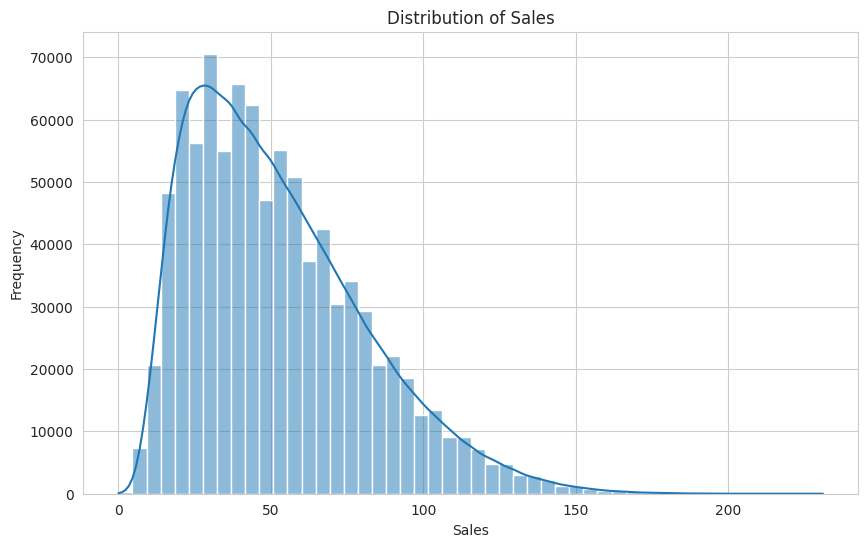

In [11]:
# Distribution of sales

plt.figure(figsize=(10,6))

sns.histplot(
    train_df['sales'],
    bins=50,
    kde=True
)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

## 📈 Sales Trend Over Time

Before building forecasting models, we first need to understand how sales change over time.

In this section, we explore the overall sales trend to identify:

- Long-term trends
- Seasonality patterns
- Sales fluctuations over time

Understanding historical behavior is essential for building effective forecasting models.

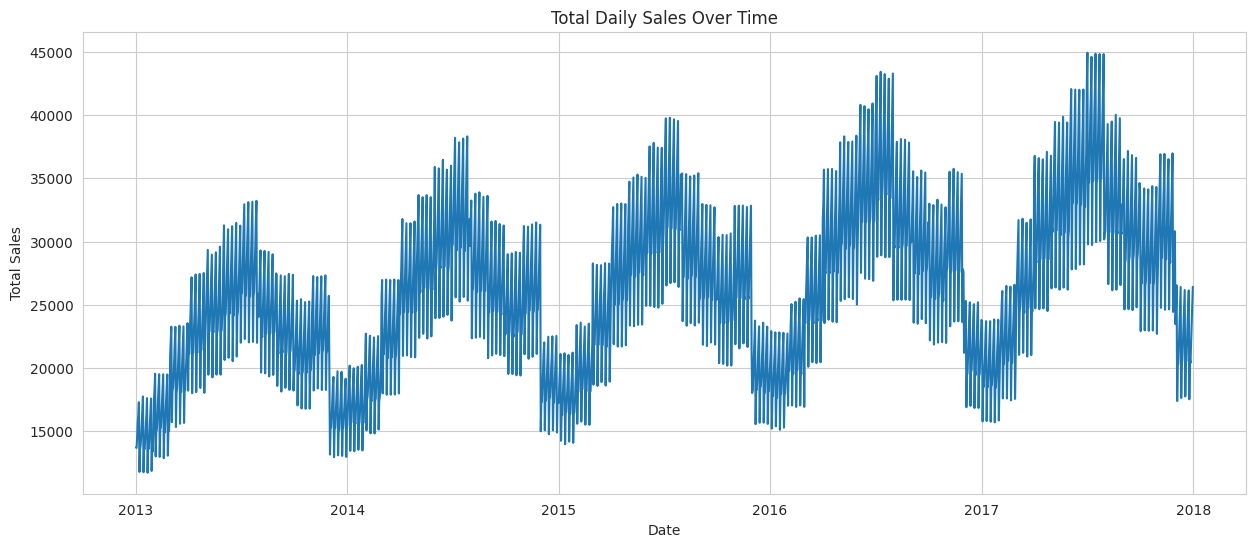

In [12]:
# Aggregate daily sales

daily_sales = train_df.groupby('date')['sales'].sum()

# Plot sales trend

plt.figure(figsize=(15,6))

plt.plot(daily_sales)

plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.show()

## 📅 Weekly Sales Pattern

To better understand weekly behavior, we analyze sales across days of the week.

This helps us identify whether certain days consistently generate higher or lower sales.

Understanding weekly seasonality is important because recurring weekly patterns can significantly improve forecasting performance.

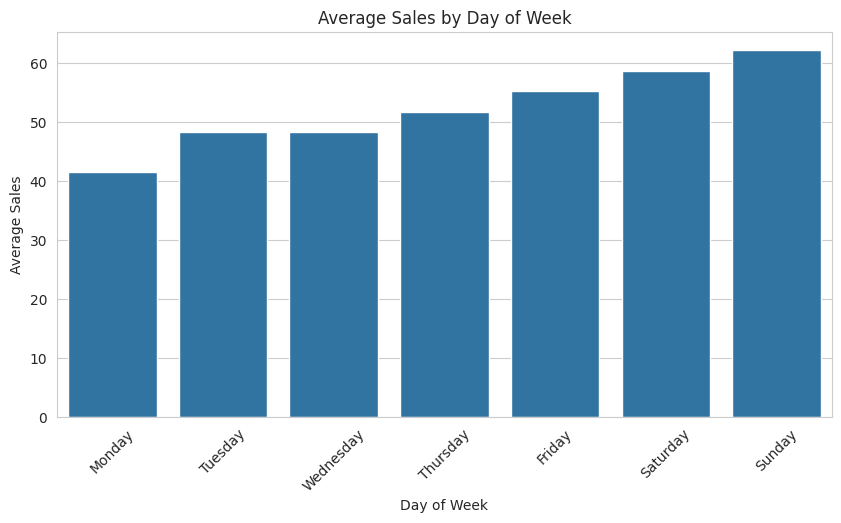

In [13]:
# Create day name

train_df['day_name'] = train_df['date'].dt.day_name()

# Average sales by day of week

weekly_sales = (
    train_df.groupby('day_name')['sales']
    .mean()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)

# Plot

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekly_sales.index,
    y=weekly_sales.values
)

plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')

plt.xticks(rotation=45)

plt.show()

## 📆 Monthly Sales Seasonality

To identify yearly seasonality patterns, we analyze average sales across months.

This helps us understand whether demand changes during specific periods of the year and whether recurring seasonal patterns exist.

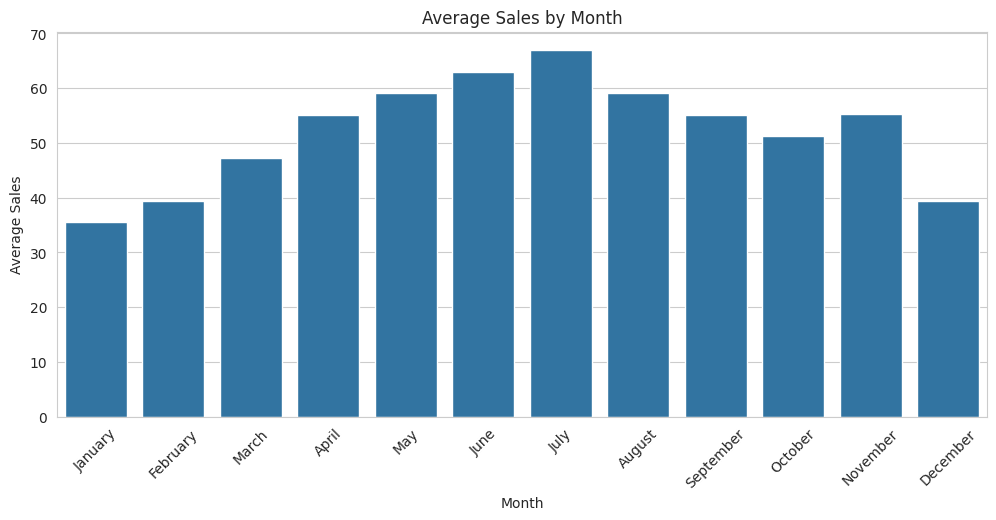

In [14]:
# Create month column

train_df['month'] = train_df['date'].dt.month_name()

# Monthly average sales

monthly_sales = (
    train_df.groupby('month')['sales']
    .mean()
    .reindex([
        'January',
        'February',
        'March',
        'April',
        'May',
        'June',
        'July',
        'August',
        'September',
        'October',
        'November',
        'December'
    ])
)

# Plot

plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')

plt.xticks(rotation=45)

plt.show()

# 🛠️ Feature Engineering

Feature engineering is one of the most important steps in time series forecasting.

Instead of relying only on raw historical data, we create meaningful features that help machine learning models better understand:

- Time-related patterns
- Weekly and yearly seasonality
- Historical demand behavior
- Sales trends over time

Well-designed features often have a major impact on forecasting performance.

In [15]:
# Create time-based features

for df in [train_df, test_df]:

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_week'] = df['date'].dt.dayofweek
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("Time features created successfully ✅")

Time features created successfully ✅


In [16]:
train_df.head()

,date,store,item,sales,day_name,month,year,day,day_of_week,week_of_year,quarter,is_weekend
0,2013-01-01,1,1,13,Tuesday,1,2013,1,1,1,1,0
1,2013-01-02,1,1,11,Wednesday,1,2013,2,2,1,1,0
2,2013-01-03,1,1,14,Thursday,1,2013,3,3,1,1,0
3,2013-01-04,1,1,13,Friday,1,2013,4,4,1,1,0
4,2013-01-05,1,1,10,Saturday,1,2013,5,5,1,1,1


## ⏳ Lag Features

Historical demand is one of the strongest signals in forecasting.

To help the model learn from past behavior, we create lag features that capture previous sales values.

For example:

- **lag_1** → sales from the previous day  
- **lag_7** → sales from the same day last week  
- **lag_30** → sales from approximately one month ago

These features help the model understand recurring demand patterns and historical trends.

In [17]:
# Create lag features

lag_days = [1, 7, 30]

for lag in lag_days:

    train_df[f'lag_{lag}'] = (
        train_df
        .groupby(['store', 'item'])['sales']
        .shift(lag)
    )

print("Lag features created successfully ✅")

Lag features created successfully ✅


In [18]:
train_df.head(10)

,date,store,item,sales,day_name,month,year,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30
0,2013-01-01,1,1,13,Tuesday,1,2013,1,1,1,1,0,NaN,NaN,NaN
1,2013-01-02,1,1,11,Wednesday,1,2013,2,2,1,1,0,13.0,NaN,NaN
2,2013-01-03,1,1,14,Thursday,1,2013,3,3,1,1,0,11.0,NaN,NaN
3,2013-01-04,1,1,13,Friday,1,2013,4,4,1,1,0,14.0,NaN,NaN
4,2013-01-05,1,1,10,Saturday,1,2013,5,5,1,1,1,13.0,NaN,NaN
5,2013-01-06,1,1,12,Sunday,1,2013,6,6,1,1,1,10.0,NaN,NaN
6,2013-01-07,1,1,10,Monday,1,2013,7,0,2,1,0,12.0,NaN,NaN
7,2013-01-08,1,1,9,Tuesday,1,2013,8,1,2,1,0,10.0,13.0,NaN
8,2013-01-09,1,1,12,Wednesday,1,2013,9,2,2,1,0,9.0,11.0,NaN
9,2013-01-10,1,1,9,Thursday,1,2013,10,3,2,1,0,12.0,14.0,NaN


## 📈 Rolling Features

Lag features capture a specific past value.

Rolling features help the model understand recent trends and average behavior over time.

We create rolling averages using historical sales only to avoid data leakage.

Examples:

- **rolling_mean_7** → average sales over the last 7 days  
- **rolling_mean_30** → average sales over the last 30 days

These features help smooth noisy fluctuations and improve forecasting stability.

In [19]:
# Create rolling mean features

windows = [7, 30]

for window in windows:

    train_df[f'rolling_mean_{window}'] = (
        train_df
        .groupby(['store', 'item'])['sales']
        .shift(1)
        .rolling(window=window)
        .mean()
    )

print("Rolling features created successfully ✅")

Rolling features created successfully ✅


In [20]:
train_df.head(40)

,date,store,item,sales,day_name,month,year,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2013-01-01,1,1,13,Tuesday,1,2013,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,Wednesday,1,2013,2,2,1,1,0,13.0,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,Thursday,1,2013,3,3,1,1,0,11.0,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,Friday,1,2013,4,4,1,1,0,14.0,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,Saturday,1,2013,5,5,1,1,1,13.0,NaN,NaN,NaN,NaN
5,2013-01-06,1,1,12,Sunday,1,2013,6,6,1,1,1,10.0,NaN,NaN,NaN,NaN
6,2013-01-07,1,1,10,Monday,1,2013,7,0,2,1,0,12.0,NaN,NaN,NaN,NaN
7,2013-01-08,1,1,9,Tuesday,1,2013,8,1,2,1,0,10.0,13.0,NaN,11.857143,NaN
8,2013-01-09,1,1,12,Wednesday,1,2013,9,2,2,1,0,9.0,11.0,NaN,11.285714,NaN
9,2013-01-10,1,1,9,Thursday,1,2013,10,3,2,1,0,12.0,14.0,NaN,11.428571,NaN


## 🧹 Handling Missing Values from Time Features

Lag and rolling features naturally create missing values at the beginning of each time series.

This happens because the model does not yet have enough historical information to calculate previous sales or rolling averages.

Since the dataset is large, we remove these rows to ensure clean and reliable model training.

In [21]:
# Remove rows with missing values from lag & rolling features

print("Shape before cleaning:", train_df.shape)

train_df = train_df.dropna()

print("Shape after cleaning:", train_df.shape)

Shape before cleaning: (913000, 17)
Shape after cleaning: (898000, 17)


## 🎯 Feature Selection

Before training the model, we separate:

- **Features (X)** → input variables used for prediction  
- **Target (y)** → the value we want to forecast (`sales`)

The model will learn patterns from historical features to predict future demand.

In [22]:
# Features available in both train and test at this stage

features = [
    'store',
    'item',
    'month',
    'year',
    'day',
    'day_of_week',
    'week_of_year',
    'quarter',
    'is_weekend'
]

X_train = train_df[features]
y_train = train_df['sales']

X_test = test_df[features]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (898000, 9)
y_train shape: (898000,)
X_test shape: (45000, 9)


## 🧪 Time-Based Validation Split

In time series forecasting, we must preserve the chronological order of data.

Instead of random splitting, we train on historical data and validate on future periods.

This better simulates real-world forecasting behavior.

In [23]:
# Time-based train-validation split

split_date = '2017-10-01'

train_data = train_df[train_df['date'] < split_date]
val_data = train_df[train_df['date'] >= split_date]

print("Training set shape:", train_data.shape)
print("Validation set shape:", val_data.shape)

Training set shape: (852000, 17)
Validation set shape: (46000, 17)


In [24]:
# Features for modeling

features = [
    'store',
    'item',
    'month',
    'year',
    'day',
    'day_of_week',
    'week_of_year',
    'quarter',
    'is_weekend',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30'
]

X_train = train_data[features]
y_train = train_data['sales']

X_val = val_data[features]
y_val = val_data['sales']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (852000, 14)
y_train: (852000,)
X_val: (46000, 14)
y_val: (46000,)


# 🌲 Baseline Model - Random Forest Regressor

We begin with a Random Forest model as a strong baseline for tabular forecasting problems.

Random Forest can capture nonlinear relationships and interactions between features, making it suitable for retail demand prediction.

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_val)

# Metrics
mae = mean_absolute_error(y_val, rf_preds)
rmse = np.sqrt(mean_squared_error(y_val, rf_preds))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 6.21
RMSE: 8.10


# 🚀 Gradient Boosting Regressor

Gradient Boosting builds trees sequentially, where each new tree learns from the errors of previous trees.

Unlike Random Forest, which trains trees independently, Gradient Boosting focuses on gradually improving predictions.

This model is commonly used to capture complex nonlinear relationships and improve forecasting accuracy.

In [26]:
# Import model
from sklearn.ensemble import GradientBoostingRegressor

# Initialize model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predictions
gb_preds = gb_model.predict(X_val)

# Metrics
mae_gb = mean_absolute_error(y_val, gb_preds)
rmse_gb = np.sqrt(mean_squared_error(y_val, gb_preds))

print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")

MAE: 6.04
RMSE: 7.84


# ⚡ XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is an advanced boosting algorithm designed for high performance and accuracy.

Like Gradient Boosting, it learns sequentially from prediction errors, but includes additional optimizations such as regularization, faster computation, and better handling of complex patterns.

XGBoost is widely used in forecasting competitions and structured/tabular machine learning problems.

In [27]:
# Import model
from xgboost import XGBRegressor

# Initialize model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
xgb_preds = xgb_model.predict(X_val)

# Metrics
mae_xgb = mean_absolute_error(y_val, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_val, xgb_preds))

print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")

MAE: 6.02
RMSE: 7.81


# 📊 Model Comparison

We trained and evaluated three tree-based models for demand forecasting:

- Random Forest
- Gradient Boosting
- XGBoost

The models were compared using:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**

The best-performing model will be selected for final forecasting.

In [28]:
# Model comparison table

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost'],
    'MAE': [mae, mae_gb, mae_xgb],
    'RMSE': [rmse, rmse_gb, rmse_xgb]
})

comparison = comparison.sort_values(by='MAE')

comparison

,Model,MAE,RMSE
2,XGBoost,6.022735,7.806484
1,Gradient Boosting,6.041614,7.836396
0,Random Forest,6.213572,8.103096


# 🔥 Feature Importance Analysis

To understand how the model makes predictions, we analyze feature importance.

This helps identify which variables contributed the most to forecasting demand.

Understanding feature importance improves model interpretability and provides business insights into demand drivers.

In [29]:
# Feature importance from XGBoost

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
12,rolling_mean_7,0.632304
10,lag_7,0.233083
13,rolling_mean_30,0.075569
5,day_of_week,0.024810
9,lag_1,0.021211
2,month,0.004162
4,day,0.003620
6,week_of_year,0.003486
11,lag_30,0.001158
0,store,0.000264


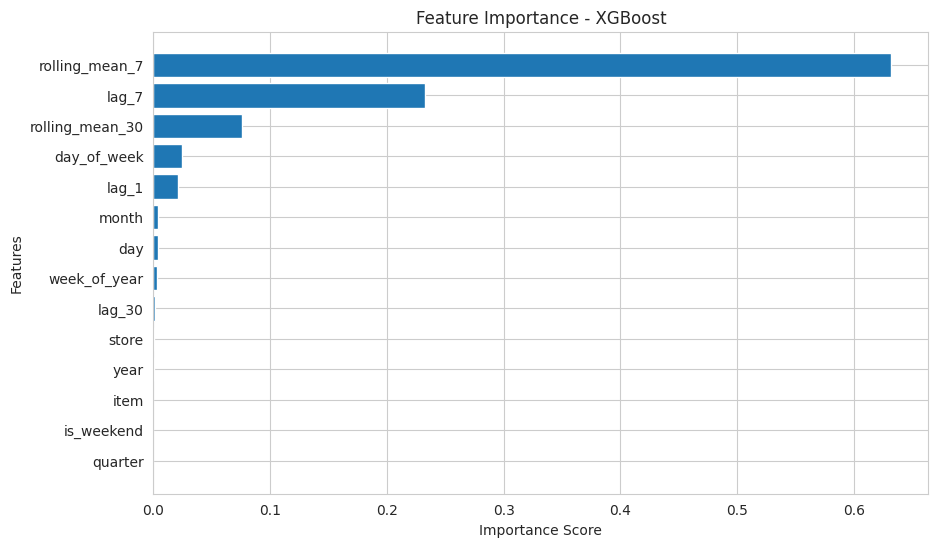

In [30]:
# Plot feature importance

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost")

plt.gca().invert_yaxis()

plt.show()

# 🔮 Final Forecasting on Test Data

After selecting XGBoost as the final model, we use it to generate sales predictions for the test dataset.

The test dataset does not include the target variable (`sales`), so lag and rolling features cannot be calculated directly from test data.

To solve this, we use the most recent historical sales from the training dataset as a starting point for forecasting.

This allows the model to create historical context for future predictions.

## 🧠 Building Historical Context for Test Forecasting

Lag and rolling features depend on past sales values.

Since the test period starts immediately after the training period, we use the latest available sales history from the training data to create the initial forecasting context.

In [31]:
# Retrain final XGBoost model on the full cleaned training data

X_full_train = train_df[features]
y_full_train = train_df['sales']

final_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

final_model.fit(X_full_train, y_full_train)

print("Final XGBoost model trained successfully ✅")

Final XGBoost model trained successfully ✅


In [32]:
# Prepare historical data and test data for recursive forecasting

history_df = train_df[['date', 'store', 'item', 'sales']].copy()

test_future = test_df[['id', 'date', 'store', 'item']].copy()
test_future['sales'] = np.nan

# Combine train history with future test period
combined_df = pd.concat(
    [history_df, test_future],
    ignore_index=True
)

combined_df = combined_df.sort_values(['store', 'item', 'date']).reset_index(drop=True)

print("Combined dataset prepared successfully ✅")
print(combined_df.tail())

Combined dataset prepared successfully ✅
             date  store  item  sales       id
942995 2018-03-27     10    50    NaN  44995.0
942996 2018-03-28     10    50    NaN  44996.0
942997 2018-03-29     10    50    NaN  44997.0
942998 2018-03-30     10    50    NaN  44998.0
942999 2018-03-31     10    50    NaN  44999.0


In [33]:
def create_forecasting_features(df):
    df = df.copy()

    # Time features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_week'] = df['date'].dt.dayofweek
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # Lag features
    df['lag_1'] = df.groupby(['store', 'item'])['sales'].shift(1)
    df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
    df['lag_30'] = df.groupby(['store', 'item'])['sales'].shift(30)

    # Rolling features
    df['rolling_mean_7'] = (
        df.groupby(['store', 'item'])['sales']
        .shift(1)
        .rolling(window=7)
        .mean()
    )

    df['rolling_mean_30'] = (
        df.groupby(['store', 'item'])['sales']
        .shift(1)
        .rolling(window=30)
        .mean()
    )

    return df

In [34]:
# Recursive forecasting for test period

test_dates = sorted(test_df['date'].unique())

predictions = []

for current_date in test_dates:

    # Recreate features using all available history and previous predictions
    combined_df = create_forecasting_features(combined_df)

    # Select rows for the current test date
    current_rows = combined_df[
        (combined_df['date'] == current_date) &
        (combined_df['sales'].isna())
    ].copy()

    # Prepare features
    X_current = current_rows[features]

    # Predict sales
    current_preds = final_model.predict(X_current)

    # Avoid negative predictions
    current_preds = np.maximum(current_preds, 0)

    # Store predictions
    current_rows['predicted_sales'] = current_preds
    predictions.append(current_rows[['id', 'predicted_sales']])

    # Update combined_df with predictions as sales for future lags
    combined_df.loc[
        (combined_df['date'] == current_date) &
        (combined_df['sales'].isna()),
        'sales'
    ] = current_preds

print("Recursive forecasting completed successfully ✅")

Recursive forecasting completed successfully ✅


In [35]:
# Create submission file

submission_df = pd.concat(predictions, ignore_index=True)

submission_df = submission_df.rename(columns={
    'predicted_sales': 'sales'
})

submission_df = submission_df[['id', 'sales']]

submission_df.head()

,id,sales
0,0.0,12.709008
1,900.0,37.619022
2,1800.0,20.824280
3,2700.0,12.227637
4,3600.0,10.467952


In [36]:
# Save submission file

submission_df.to_csv('submission.csv', index=False)

print("Submission file saved successfully ✅")
print(submission_df.shape)

Submission file saved successfully ✅
(45000, 2)


In [37]:
submission_df['sales'].describe()

,sales
count,45000.000000
mean,48.957012
std,24.231060
min,7.897769
25%,28.613960
50%,45.441406
75%,65.633701
max,139.282272


# 📌 Conclusion

In this project, an end-to-end time series forecasting workflow was developed to predict future retail sales demand using machine learning.

The analysis began with exploratory data analysis (EDA), which revealed important sales patterns including weekly seasonality, weekend effects, and long-term sales trends.

To improve forecasting performance, several time-based, lag, and rolling features were engineered, allowing the models to learn from historical demand behavior.

Three machine learning models were trained and compared:

- Random Forest
- Gradient Boosting
- XGBoost

Among them, XGBoost achieved the best overall performance with the lowest forecasting error.

Feature importance analysis showed that recent historical demand, especially `rolling_mean_7` and `lag_7`, played the biggest role in predicting future sales. This confirmed the weekly demand patterns discovered during EDA.

Finally, the selected model was used to generate future sales predictions for unseen test data using recursive forecasting.

Overall, this project demonstrates how historical retail data can be transformed into meaningful demand forecasts to support better inventory planning and data-driven business decisions.